In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for better visuals
plt.style.use('seaborn-v0_8')

# load data
df = pd.read_csv('../data/city_day.csv')

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [2]:
# filter Bangalore data
blr_df = df[df['City'] == 'Bengaluru'].copy()

blr_df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
4294,Bengaluru,2015-01-01,NaN,NaN,3.26,17.33,10.88,20.36,0.33,3.54,10.73,0.56,4.64,NaN,NaN,NaN
4295,Bengaluru,2015-01-02,NaN,NaN,6.05,19.73,14.14,23.74,1.35,3.97,22.77,0.65,5.31,NaN,NaN,NaN
4296,Bengaluru,2015-01-03,NaN,NaN,11.91,19.88,20.72,4.32,17.40,13.61,12.03,0.53,19.25,NaN,NaN,NaN
4297,Bengaluru,2015-01-04,NaN,NaN,7.45,21.61,16.88,0.87,5.05,6.52,17.70,0.55,7.47,NaN,NaN,NaN
4298,Bengaluru,2015-01-05,NaN,NaN,9.52,22.17,21.76,31.38,1.83,4.71,12.72,0.40,4.36,NaN,NaN,NaN


In [3]:
blr_df = blr_df[['Date', 'PM2.5']]

blr_df.head()

,Date,PM2.5
4294,2015-01-01,NaN
4295,2015-01-02,NaN
4296,2015-01-03,NaN
4297,2015-01-04,NaN
4298,2015-01-05,NaN


In [4]:
blr_df['Date'] = pd.to_datetime(blr_df['Date'])
blr_df.set_index('Date', inplace=True)

blr_df.head()

,PM2.5
Date,
2015-01-01,NaN
2015-01-02,NaN
2015-01-03,NaN
2015-01-04,NaN
2015-01-05,NaN


In [8]:
blr_df.isnull().sum()

PM2.5    146
MA_30    442
dtype: int64

In [9]:
blr_df = blr_df.dropna()

In [10]:
blr_df.info()
blr_df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 1567 entries, 2015-04-18 to 2020-07-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   1567 non-null   float64
 1   MA_30   1567 non-null   float64
dtypes: float64(2)
memory usage: 36.7 KB


,PM2.5,MA_30
count,1567.000000,1567.000000
mean,35.239158,35.522772
std,20.124584,13.231478
min,1.720000,16.542667
25%,21.035000,23.186500
50%,30.650000,34.890667
75%,44.265000,43.428000
max,239.540000,75.852667


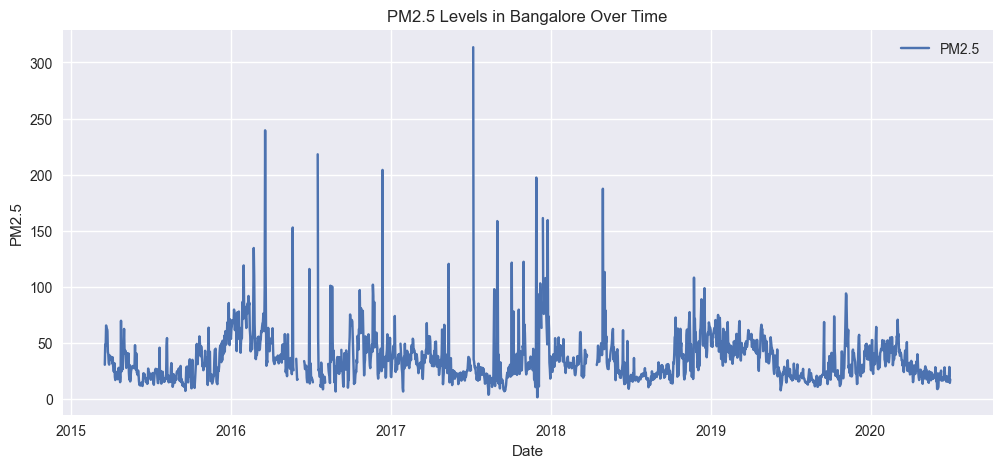

In [5]:
# Plot PM2.5 Trend
plt.figure(figsize=(12,5))
plt.plot(blr_df['PM2.5'], label='PM2.5')
plt.title('PM2.5 Levels in Bangalore Over Time')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

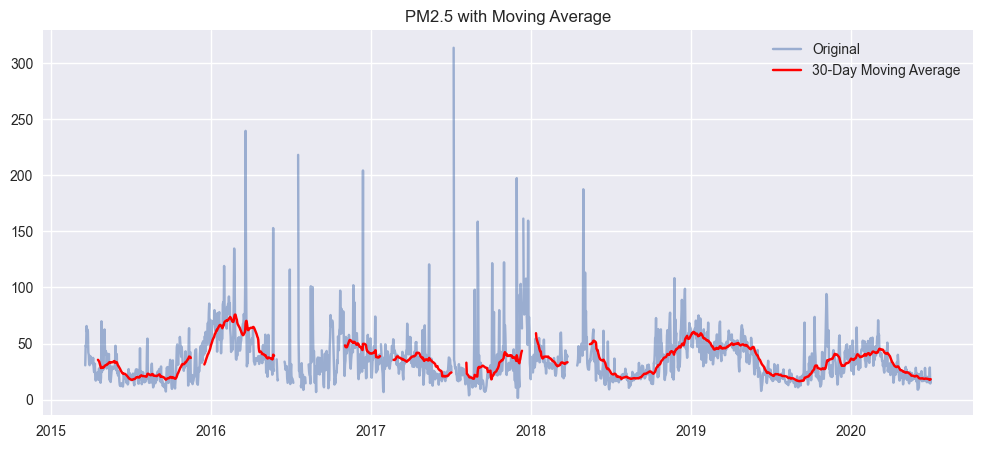

In [6]:
# Moving Average (Smoothing) This helps remove noise and show the trend clearly.

blr_df['MA_30'] = blr_df['PM2.5'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(blr_df['PM2.5'], label='Original', alpha=0.5)
plt.plot(blr_df['MA_30'], label='30-Day Moving Average', color='red')
plt.title('PM2.5 with Moving Average')
plt.legend()
plt.show()

In [7]:
# Time Series Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(blr_df['PM2.5'], model='additive', period=365)

decomposition.plot()
plt.show()

ValueError: This function does not handle missing values